<a href="https://colab.research.google.com/github/joonookwak/Deep-Generative-Models-Practice/blob/main/Diffusion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DDPM (Denoising Diffusion Probabilistic Models)

"U-Net 모델에게 완벽한 노이즈 이미지를 보여주면서, **'방금 입혀진 미세한 노이즈를 맞추고 걷어내 봐!'**라고 훈련시키는 것"

1. 정방향 과정 (Forward Process - 모래성 부수기)
2. 역방향 과정 (Reverse Process - 시간 되돌리기)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# --- 0. 기본 세팅 (새벽반 복습!) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64 # 디퓨전은 훈련이 안정적이라 배치를 조금 줄여도 됩니다.
print(f"🚀 디퓨전 특훈 장치: {device}")

# MNIST 데이터 로딩
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # ⭐️ 중요: 디퓨전은 데이터를 [-1, 1] 사이로 맞춥니다!
])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

🚀 디퓨전 특훈 장치: cuda


🎨 숫자가 어떻게 완벽한 노이즈로 변하는지 감상하세요 (Forward Process)


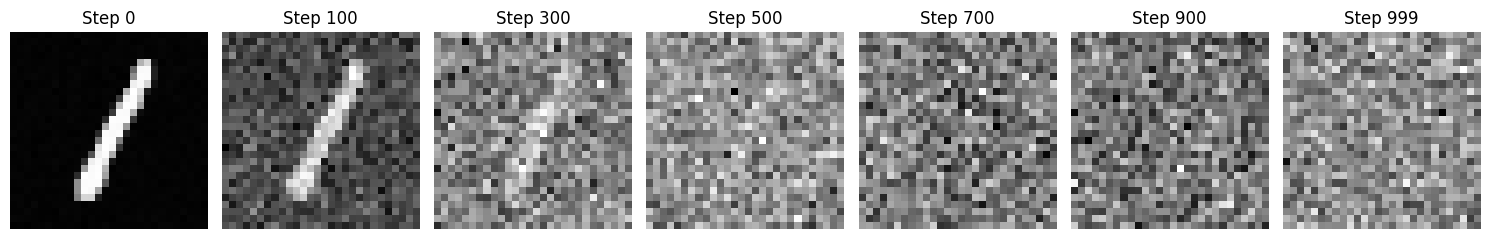

In [ ]:
# --- 1. 노이즈 스케줄링 (Linear Schedule) ---
T = 1000 # ⭐️ 시간 단계 (T).

# 파도가 치는 강도 (베타, beta) 설정: 0.0001에서 0.02로 점점 세지게 함.
betas = torch.linspace(0.0001, 0.02, T).to(device)

# 수학적 계산을 위한 유틸리티 값들 미리 계산해두기 : Reparameterization Trick
# 여기서 아주 심각한 문제가 생깁니다. 만약 "세탁기 500번 돌린 상태의 옷"을 만들려면, for문을 써서 노이즈를 1번부터 500번까지 순차적으로 계속 더해야 할까요? 그러면 연산이 너무 오래 걸리겠죠.
# 그래서 수학자들이 **"한 방에 500번째 상태로 점프하는 공식"**을 만들어냅니다. --> 마르코프 연쇄 성질
alphas = 1. - betas # 알파
alphas_cumprod = torch.cumprod(alphas, dim=0) # 알파의 누적 곱 --> Markovian property
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod) # 원본 보존율
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod) # 노이즈 비율

# 원하는 시간 단계(t)의 sqrt_alphas_cumprod 값만 쏙 빼오는 유틸리티 함수
def get_index_from_list(vals, t, x_shape):
    batch_size = t.shape[0]
    out = vals.gather(-1, t.to(vals.device)) # ⭐️ vals가 있는 곳(GPU)으로 t도 보내기!
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

# --- 2. 정방향 과정 (Forward Process: q-sampling) ---
# 원본 이미지(x_0)에 특정 시간(t)만큼 노이즈를 확 뿌려버리는 함수
def forward_diffusion_sample(x_0, t, device=device):
    # ① 섞어줄 완벽한 가우시안 노이즈 생성 ($\ε$)
    noise = torch.randn_like(x_0)

    # ② 수학 공식 적용: x_t = (원본 비율)*x_0 + (노이즈 비율)*noise
    # 이 sqrt 값들이 시간 t가 지날수록 원본은 줄이고 노이즈는 늘리는 비율입니다.
    sqrt_alphas_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_t = get_index_from_list(sqrt_one_minus_alphas_cumprod, t, x_0.shape)

    # ③ 노이즈 섞기!
    return sqrt_alphas_t.to(device) * x_0.to(device) \
           + sqrt_one_minus_alphas_t.to(device) * noise.to(device), noise.to(device)


# --- 3. 정방향 과정(모래성 부수기) 시각화 ---
print("🎨 숫자가 어떻게 완벽한 노이즈로 변하는지 감상하세요 (Forward Process)")
plt.figure(figsize=(15, 3))

# 컨베이어 벨트에서 숫자 한 개 꺼내기
images, _ = next(iter(train_loader))
x_0 = images[0:1] # 숫자 하나만 쏙 빼기

# 시간 단계 T (200) 중 7 단계를 골라서 시각화
step_idxs = [0, 100, 300, 500, 700, 900, 999]

for i, t_step in enumerate(step_idxs):
    t = torch.Tensor([t_step]).type(torch.int64).to(device) # Moved 't' to the device
    x_t, _ = forward_diffusion_sample(x_0, t)

    # 시각화 (데이터가 [-1, 1]이라 다시 [0, 1]로 풀어서 보여줍니다.)
    plt.subplot(1, len(step_idxs), i + 1)
    plt.imshow(x_t.squeeze().cpu().numpy() * 0.5 + 0.5, cmap='gray')
    plt.title(f"Step {t_step}")
    plt.axis('off')

plt.tight_layout()
plt.show()


여기까진 AI개입 없음. 그저 수학적 계산으로 노이즈를 입히는 것.

In [ ]:
# U-Net 모델 생성
import torch.nn as nn

class TimeConditionedUNet(nn.Module):
    def __init__(self):
        super(TimeConditionedUNet, self).__init__()

        # ⭐️ 정석의 핵심: '현재 몇 번째 스텝(t)인가?'를 모델이 이해할 수 있게 변환하는 부품
        self.time_embed = nn.Embedding(1000, 128) # T=1000

        # --- 1. 엔코더 (Encoder - 이미지 축소하며 특징 찾기) ---
        # [배치, 1, 28, 28] -> [배치, 64, 28, 28]
        self.down1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2) # 크기 절반으로 뚝! (14x14)

        # [배치, 64, 14, 14] -> [배치, 128, 14, 14]
        self.down2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # --- 2. 바닥 (Bottleneck - 가장 압축된 상태) ---
        # 14x14를 7x7로 한 번 더 줄임
        self.bot1 = nn.Conv2d(128, 128, kernel_size=3, padding=1)

        # --- 3. 디코더 (Decoder - 이미지 다시 확대하기) ---
        # 7x7 -> 14x14 로 확대
        self.up1_trans = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        # ⭐️ 스킵 커넥션: 방금 확대한 64 + 아까 압축할 때 빼둔 128 = 192채널
        self.up_conv1 = nn.Conv2d(192, 64, kernel_size=3, padding=1)

        # 14x14 -> 28x28 로 최종 확대
        self.up2_trans = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        # ⭐️ 스킵 커넥션: 방금 확대한 32 + 맨 처음 빼둔 64 = 96채널
        self.up_conv2 = nn.Conv2d(96, 1, kernel_size=3, padding=1) # 최종 출력은 1채널(흑백)

    def forward(self, x, t):
        # 1. 시간(t) 정보 가져오기
        t_emb = self.time_embed(t).view(-1, 128, 1, 1)

        # 2. 내려가기 (Encoder)
        x1 = F.relu(self.down1(x)) # 첫 번째 커닝 페이퍼
        x1_p = self.pool(x1)

        x2 = F.relu(self.down2(x1_p)) # 두 번째 커닝 페이퍼
        x2_p = self.pool(x2)

        # 3. 바닥 찍고 시간 정보 합치기!
        bot = F.relu(self.bot1(x2_p))
        bot = bot + t_emb # "지금 t번째 스텝의 노이즈야!" 라고 모델 뇌리에 콱 박아줌

        # 4. 올라가기 (Decoder & Skip Connection)
        up1 = self.up1_trans(bot)
        merge1 = torch.cat([up1, x2], dim=1) # 커닝 페이퍼(x2) 이어 붙이기!
        up1 = F.relu(self.up_conv1(merge1))

        up2 = self.up2_trans(up1)
        merge2 = torch.cat([up2, x1], dim=1) # 커닝 페이퍼(x1) 이어 붙이기!

        # 디퓨전에서는 노이즈(숫자값) 자체를 예측하므로
        # Sigmoid나 Tanh 없이 있는 그대로 선형 출력합니다.
        out = self.up_conv2(merge2)

        return out

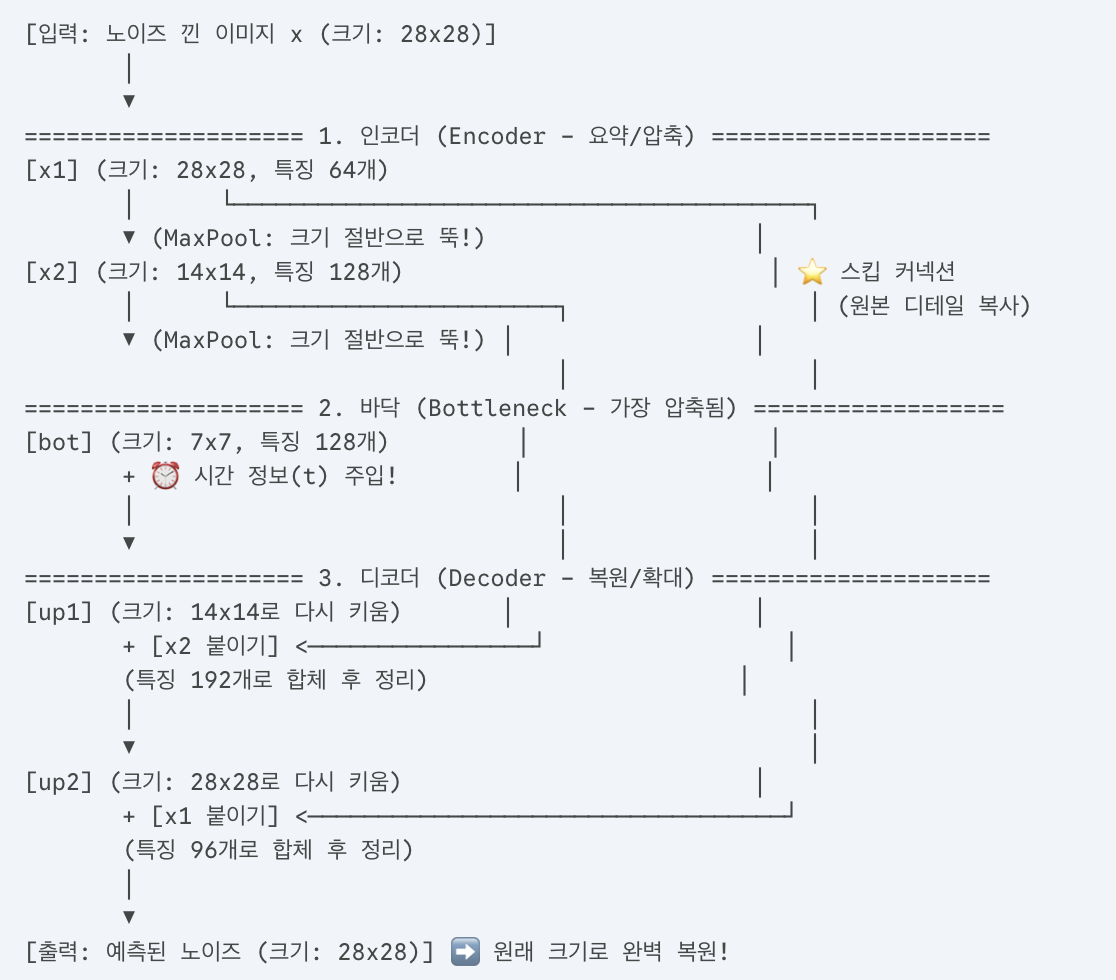

**"생겨 먹은 건 VAE랑 똑같다"**가 맞습니다!

하지만 그 똑같이 생긴 기계(U-Net)를,

그림이 아니라 **'노이즈'**를 예측하도록 학습시키고, -> 여기까지가 윗 코드

**t=1000부터 t=0까지 시간을 거꾸로 세어가며 '1000번 연속으로' 작동**시켰기 때문에! -> 아래 코드에서 나옴

이 전체 과정을 **'시간 되돌리기(Reverse Process)'**라고 부르는 것입니다.

In [ ]:

# 훈련 시작
import torch.optim as optim

# 1. 뇌(모델), 코치, 심판 모셔오기
model = TimeConditionedUNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss() # 심판: "진짜 노이즈랑 네가 예측한 노이즈가 얼마나 차이나니?"
'''
epochs = 5 # 수면 시간을 지키기 위한 5번의 압축 훈련!

print("🔥 디퓨전 정석 훈련을 시작합니다! (팬 돌아가는 소리 주의)")

# 훈련 시작!
for epoch in range(epochs):
    epoch_loss = 0
    for batch_idx, (real_images, _) in enumerate(train_loader):
        batch_size = real_images.shape[0]
        real_images = real_images.to(device)

        optimizer.zero_grad()

        # ① 1000단계 중 무작위로 시간(t) 하나씩 뽑기 (예: "너는 300번째 스텝, 너는 850번째 스텝!")
        t = torch.randint(0, T, (batch_size,)).type(torch.int64).to(device)

        # ② 아까 만든 공식으로 '진짜 노이즈'를 확 들이붓기 (문제지 만들기)
        noisy_images, actual_noise = forward_diffusion_sample(real_images, t, device)

        # ③ 모델 등판: "이 노이즈 낀 사진이랑 시간 t를 보니까... 이만큼 노이즈가 들어간 것 같아!"
        predicted_noise = model(noisy_images, t)

        # ④ 심판 판정: 진짜 들어간 노이즈 vs 모델이 찍은 노이즈 비교
        loss = criterion(actual_noise, predicted_noise)

        # ⑤ 반성하고 실력 키우기
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1:02d}/{epochs}] | Loss: {epoch_loss/len(train_loader):.4f}")
    '''

🔥 디퓨전 정석 훈련을 시작합니다! (팬 돌아가는 소리 주의)
Epoch [01/5] | Loss: 0.1003
Epoch [02/5] | Loss: 0.0613
Epoch [03/5] | Loss: 0.0535
Epoch [04/5] | Loss: 0.0507
Epoch [05/5] | Loss: 0.0478


🪄 마법의 지우개질 1000번 시작! (시간 되돌리기)


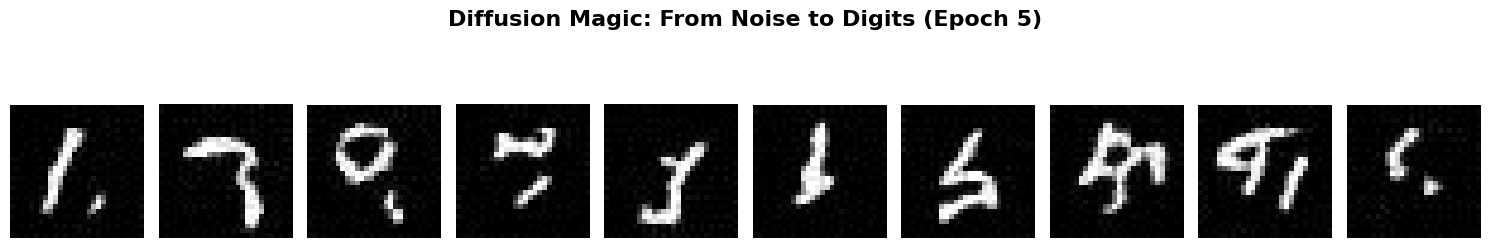

In [ ]:

@torch.no_grad() # 훈련이 아니니까 심판(기울기 계산)은 퇴근!
def sample_images(model, n_samples=10, device=device):
    print("🪄 마법의 지우개질 1000번 시작! (시간 되돌리기)")
    model.eval() # 실전 모드 ON

    # 1. 스케치북 준비: 아무 의미 없는 완벽한 가우시안 노이즈 10장 던져주기
    x = torch.randn((n_samples, 1, 28, 28)).to(device)

    # 2. 1000단계에서 0단계로 거꾸로 카운트다운! (Reverse Process) !!!!!!!!!!!!!!!!!!!!!! 이게 핵심 !!!!!!!!!!!!!!!!!!!!!!!!
    for i in reversed(range(T)):
        # 현재 몇 번째 스텝(t)인지 모델에게 알려주기 위한 세팅
        t = torch.full((n_samples,), i, device=device, dtype=torch.long)

        # ⭐️ U-Net 등판: "이 노이즈 덩어리에서 네가 생각하는 '들어간 노이즈'를 예측해 봐!"
        predicted_noise = model(x, t)

        # 디퓨전 지우개 수학 공식에 쓸 재료들 (알파, 베타)
        alpha_t = alphas[i]
        alpha_t_cumprod = alphas_cumprod[i]
        beta_t = betas[i]

        # 3. 핵심 공식: 현재 그림(x)에서 예측한 노이즈(predicted_noise)를 미세하게 빼줍니다.
        x = (1.0 / torch.sqrt(alpha_t)) * (x - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_t_cumprod)) * predicted_noise)

        # 4. 디퓨전의 꿀팁: 다 지우고 약간의 노이즈를 다시 섞어주면 그림이 훨씬 예뻐집니다! (Langevin dynamics)
        # 단, 마지막 0단계(완성)에서는 노이즈를 섞지 않습니다.
        if i > 0:
            noise = torch.randn_like(x)
            x = x + torch.sqrt(beta_t) * noise

    # 완성된 그림을 -1~1 범위에서 우리가 볼 수 있는 0~1 범위로 쫙 펴주기
    x = (x.clamp(-1, 1) + 1) / 2
    return x.cpu()
'''
# --- 결과 전시회 오픈 ---
# GPU가 1000번의 U-Net 연산을 해야 해서 한 10~20초 정도 걸립니다!
generated_images = sample_images(model, n_samples=10)

plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Diffusion Magic: From Noise to Digits (Epoch 5)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
'''

🔥 50 Epoch 훈련 시작! 외출 다녀오세요~ 컴퓨터가 알아서 일합니다.
Epoch [01/50] | Loss: 0.0439
Epoch [02/50] | Loss: 0.0429
Epoch [03/50] | Loss: 0.0424
Epoch [04/50] | Loss: 0.0420
Epoch [05/50] | Loss: 0.0413
Epoch [06/50] | Loss: 0.0412
Epoch [07/50] | Loss: 0.0403
Epoch [08/50] | Loss: 0.0404
Epoch [09/50] | Loss: 0.0405
Epoch [10/50] | Loss: 0.0397
Epoch [11/50] | Loss: 0.0395
Epoch [12/50] | Loss: 0.0391
Epoch [13/50] | Loss: 0.0390
Epoch [14/50] | Loss: 0.0385
Epoch [15/50] | Loss: 0.0386
Epoch [16/50] | Loss: 0.0384
Epoch [17/50] | Loss: 0.0385
Epoch [18/50] | Loss: 0.0386
Epoch [19/50] | Loss: 0.0379
Epoch [20/50] | Loss: 0.0382
Epoch [21/50] | Loss: 0.0380
Epoch [22/50] | Loss: 0.0381
Epoch [23/50] | Loss: 0.0377
Epoch [24/50] | Loss: 0.0372
Epoch [25/50] | Loss: 0.0378
Epoch [26/50] | Loss: 0.0371
Epoch [27/50] | Loss: 0.0376
Epoch [28/50] | Loss: 0.0370
Epoch [29/50] | Loss: 0.0369
Epoch [30/50] | Loss: 0.0371
Epoch [31/50] | Loss: 0.0367
Epoch [32/50] | Loss: 0.0370
Epoch [33/50] | Loss: 0.0366


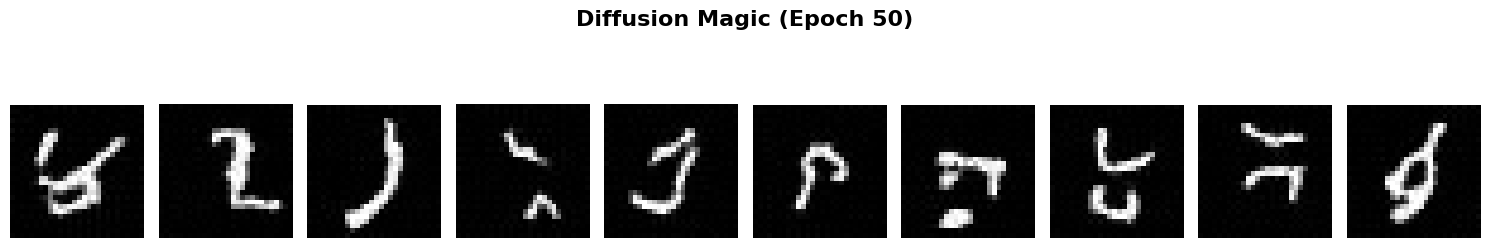

In [ ]:
epochs = 50 # ⭐️ 대망의 50 에포크!

print(f"🔥 {epochs} Epoch 훈련 시작! 외출 다녀오세요~ 컴퓨터가 알아서 일합니다.")

# --- 1. 훈련 시작 ---
for epoch in range(epochs):
    epoch_loss = 0
    for batch_idx, (real_images, _) in enumerate(train_loader):
        batch_size = real_images.shape[0]
        real_images = real_images.to(device)
        optimizer.zero_grad()

        t = torch.randint(0, T, (batch_size,)).type(torch.int64).to(device)
        noisy_images, actual_noise = forward_diffusion_sample(real_images, t, device)

        predicted_noise = model(noisy_images, t)
        loss = criterion(actual_noise, predicted_noise)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1:02d}/{epochs}] | Loss: {epoch_loss/len(train_loader):.4f}")

# --- 2. 훈련 끝난 직후 뇌(가중치) 안전하게 저장하기 ---
torch.save(model.state_dict(), 'diffusion_unet_50ep.pth')
print("💾 50 에포크 학습 완료! 모델이 'diffusion_unet_50ep.pth'로 안전하게 저장되었습니다.")

# --- 3. 바로 이어서 결과물(그림) 뽑아놓기 ---
generated_images = sample_images(model, n_samples=10)

plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle(f"Diffusion Magic (Epoch {epochs})", fontsize=16, fontweight='bold')
plt.tight_layout()
# 코랩 환경에서 화면에 띄워두고 유지되도록 설정
plt.show()

내 이해

우선 diffusion 모델은 반복문 없이 수학적으로 마코브 체인의 성질을 이용하여 노이즈를 원하는 만큼 입혀.

그러면 원본 이미지는 알아볼 수 없는 노이즈 덩어리가 되는거지. 그 덩어리를 u-net 모델에 넣는데, u-net 모델은 내려가면서 이미지를 압축하고 올라오면서 이미지를 다시 복원해. 이 과정은 VAE와 비슷하지만 내려갈때 스킵커넥션을 복사해놓고, 바텀에서 시간 정보를 주입하고, 올라올때 복사해놓은 스킵커넥션을 붙인다는 차이가 있지. 그렇게 노이즈를 복원해 내는 모델이야.

그런뒤 이 모델을 MSE 오차로 넣은 노이즈와 예측한 노이즈의 차이를 개선해 나가서 ai를 학습시켜.

학습이 완료되면 랜덤한 노이즈 를 던져주면 학습한 결과에 따라서 노이즈를 제거해 나가면서 이미지를 생성해내. 이것이 generative ai 이지.